In [1]:
# setup
from mlwpy import *
%matplotlib inline

iris = datasets.load_iris()
(iris_train,     iris_test, 
 iris_train_tgt, iris_test_tgt) = skms.train_test_split(iris.data,
                                                        iris.target, 
                                                        test_size=.25)

iris.feature_names = [fn[:-5] for fn in iris.feature_names]
iris_df = pd.DataFrame(iris.data,columns= iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
display(iris_df)

,sepal length,sepal width,petal length,petal width,species
0,5.1000,3.5000,1.4000,0.2000,setosa
1,4.9000,3.0000,1.4000,0.2000,setosa
2,4.7000,3.2000,1.3000,0.2000,setosa
3,4.6000,3.1000,1.5000,0.2000,setosa
4,5.0000,3.6000,1.4000,0.2000,setosa
...,...,...,...,...,...
145,6.7000,3.0000,5.2000,2.3000,virginica
146,6.3000,2.5000,5.0000,1.9000,virginica
147,6.5000,3.0000,5.2000,2.0000,virginica
148,6.2000,3.4000,5.4000,2.3000,virginica


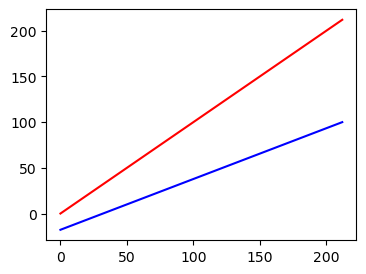

In [2]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
f_temps = np.linspace(0, 212, 100)
c_temps = (5/9) * (f_temps - 32)
plt.plot(f_temps, f_temps, 'r',  # F -> F
         f_temps, c_temps, 'b');  # F -> C

,original,scaled,hue
0,-2.5071,-0.8501,2
1,-0.8962,-0.2990,4
2,2.5555,0.8819,7
3,-2.7120,-0.9202,2
4,-4.2302,-1.4396,0
...,...,...,...
95,1.4203,0.4935,6
96,-4.1586,-1.4151,0
97,-3.3837,-1.1500,1
98,3.9855,1.3711,8


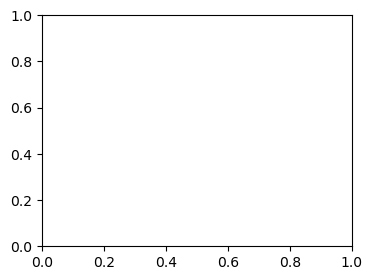

In [3]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
original = np.random.uniform(-5,5,100)
scaled = skpre.StandardScaler().fit_transform(original.reshape(-1,1))[:,0]
bins = np.floor(original).astype(np.uint8) + 5
df = pd.DataFrame({
    "original":original,
    "scaled":scaled,
    "hue":bins
})
display(df)


In [4]:
df = pd.melt(df,id_vars='hue',var_name='scale')
display(df)

,hue,scale,value
0,2,original,-2.5071
1,4,original,-0.8962
2,7,original,2.5555
3,2,original,-2.7120
4,0,original,-4.2302
...,...,...,...
195,6,scaled,0.4935
196,0,scaled,-1.4151
197,1,scaled,-1.1500
198,8,scaled,1.3711


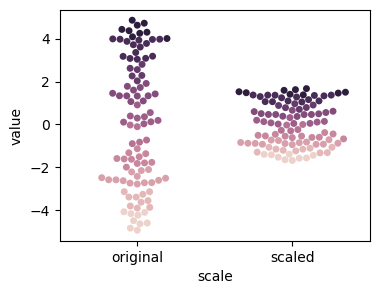

In [5]:
sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()


C:\Users\Ritik\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 74.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 53.3% of the points

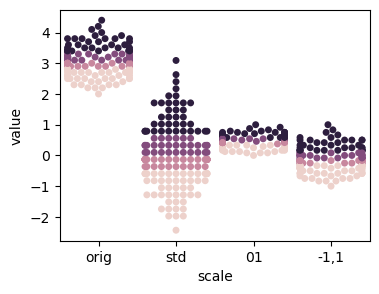

In [6]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

bins = pd.cut(iris_df['sepal width'], 
              np.percentile(iris_df['sepal width'], 
                            [25, 50, 75, 100])).cat.codes

df = pd.DataFrame({'orig':iris_df['sepal width'],
                   'hue':bins})

scalers = [('std', skpre.StandardScaler()),
           ('01' , skpre.MinMaxScaler()),
           ('-1,1', skpre.MinMaxScaler((-1,1)))]

for name, scaler in scalers:
     # ugly:  [[]] to keep 2D for sklearn
     #        reshape(-1) to go back to 1-D for seaborn  :(
    df[name] = scaler.fit_transform(df[['orig']]).reshape(-1)

df = pd.melt(df, id_vars='hue', var_name='scale')
sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()

In [7]:
iris_df = pd.DataFrame(iris.data,columns = iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
display(iris_df.iloc[[0,50,100]])

,sepal length,sepal width,petal length,petal width,species
0,5.1000,3.5000,1.4000,0.2000,setosa
50,7.0000,3.2000,4.7000,1.4000,versicolor
100,6.3000,3.3000,6.0000,2.5000,virginica


C:\Users\Ritik\AppData\Local\Temp\ipykernel_17560\3368042872.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(iris_df['sepal length'],hist = False, rug = True)


Text(0, 0.5, 'Approximate %')

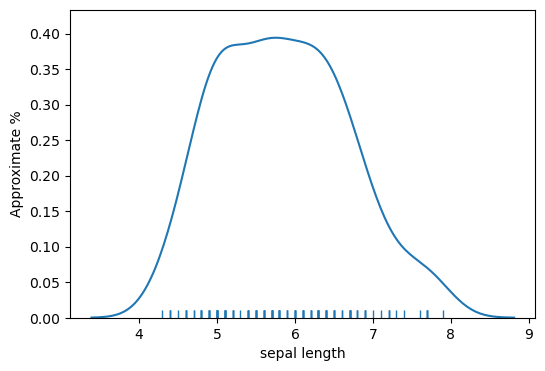

In [8]:
plt.subplots(1,1,figsize=(6,4))
ax = sns.distplot(iris_df['sepal length'],hist = False, rug = True)
ax.set_ylabel("Approximate %")

In [9]:
# apply binary threshold to numeric with sklearn is tricky
column = iris_df[['sepal length']] # keep 2Dness b/c sk complains
col_mean = column.mean().values[0]    # and sk fails with Series/DF

both = column.copy()
both['> Mean'] = skpre.binarize(column, threshold=col_mean).astype(np.bool_)

print('Column Mean:', col_mean)
display(both.iloc[[0,50,100]])

Column Mean: 5.843333333333334


,sepal length,> Mean
0,5.1000,False
50,7.0000,True
100,6.3000,True


In [10]:
sep_len_series = iris_df['sepal length']
breaks = [sep_len_series.mean(), 
          sep_len_series.max()]

# ugly to extract
print(pd.cut(sep_len_series, breaks).cat.codes[[0, 50, 100]])

0     -1
50     0
100    0
dtype: int8


In [11]:
# an easy button:
np.where(column > column.mean(), True, False)[[0,50,100]]

array([[False],
       [ True],
       [ True]])

In [12]:
# close your eyes Francis, this is about to get ugly
# this pandas voodoo is simply to produce a labelled dataframe
# so you can *see* the learning problem I am describing in the text

new_iris_df = pd.DataFrame(iris_df, columns=['petal length', 
                                             'petal width', 
                                             'species'])

new_iris_df.columns = pd.MultiIndex([['input ftrs', 'target ftr'],
                                      new_iris_df.columns], 
                                     [[1, 0, 0], [0,1,2]])

new_iris_df = new_iris_df.sort_index(axis='columns')
display(new_iris_df.iloc[[0,50,100]])

input ftrs                       target ftr
             petal width     species         petal length
0                 0.2000      setosa               1.4000
50                1.4000  versicolor               4.7000
100               2.5000   virginica               6.0000

In [13]:
print("Numerical categories:", iris.target[[0,50,100]],sep='\n')

#produces  sparse representation 
sparse = skpre.OneHotEncoder().fit_transform(iris.target.reshape(-1,1))

#densify it
print("One-hot-coding:",sparse[[0,50,100]].todense(),sep="\n")

Numerical categories:
[0 1 2]
One-hot-coding:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [14]:

# can use drop_first to get treatment coding
# can request sparse storage
encoded = pd.get_dummies(iris_df, prefix="is") 
encoded.iloc[[0,50,100]]

,sepal length,sepal width,petal length,petal width,is_setosa,is_versicolor,is_virginica
0,5.1000,3.5000,1.4000,0.2000,True,False,False
50,7.0000,3.2000,4.7000,1.4000,False,True,False
100,6.3000,3.3000,6.0000,2.5000,False,False,True


In [15]:
encoded_species = pd.get_dummies(iris.target)
encoded_df = pd.merge(iris_df,encoded_species,right_index = True,left_index = True)
encoded_df.iloc[[0,50,100]]

,sepal length,sepal width,petal length,petal width,species,0,1,2
0,5.1000,3.5000,1.4000,0.2000,setosa,True,False,False
50,7.0000,3.2000,4.7000,1.4000,versicolor,False,True,False
100,6.3000,3.3000,6.0000,2.5000,virginica,False,False,True


In [16]:
import patsy.contrasts as pc


levels = iris.target_names
coding = (pc.Treatment(reference=0).code_with_intercept(list(levels)))

print(coding)

ContrastMatrix(array([[1., 0., 0.],
                      [0., 1., 0.],
                      [0., 0., 1.]]),
               ['[setosa]', '[versicolor]', '[virginica]'])


In [17]:

encoded = patsy.dmatrix('species-1', 
                        iris_df, 
                        return_type='dataframe')
display(encoded.iloc[[0,50,100]])

,species[setosa],species[versicolor],species[virginica]
0,1.0000,0.0000,0.0000
50,0.0000,1.0000,0.0000
100,0.0000,0.0000,1.0000


In [18]:
encoded = patsy.dmatrix('species', 
                        iris_df, 
                        return_type='dataframe')
display(encoded.iloc[[0,50,100]])

,Intercept,species[T.versicolor],species[T.virginica]
0,1.0000,0.0000,0.0000
50,1.0000,1.0000,0.0000
100,1.0000,0.0000,1.0000


In [19]:
 pet_data = pd.DataFrame({
     'pet':['cat','cat','dog'],
     'cost':[20.0,25.0,40.0]
 })


In [20]:
pet_df = pd.get_dummies(pet_data)
display(pet_df)

,cost,pet_cat,pet_dog
0,20.0000,True,False
1,25.0000,True,False
2,40.0000,False,True


In [21]:
def pretty_coeffs(sk_lr_model,ftr_names):
    'helper to display sklearn results in a nice dataframe'
    lr_coeffs = pd.DataFrame(sk_lr_model.coef_,columns=ftr_names, index = ['Coeff'])
    lr_coeffs['intercept'] = sk_lr_model.intercept_
    return lr_coeffs



In [22]:
#massage
sk_tgt = pet_df['cost'].values.reshape(-1,1)
sk_ftrs = pet_df.drop('cost', axis='columns')

#build model
sk_model = (linear_model.LinearRegression(fit_intercept=False).fit(sk_ftrs,sk_tgt))

display(pretty_coeffs(sk_model,sk_ftrs.columns))

,pet_cat,pet_dog,intercept
Coeff,22.5000,40.0000,0.0000


In [23]:
import statsmodels as sm
import statsmodels.formula.api as smf

In [24]:
#patsy formula that explicitly removes an intercept
formula = 'cost ~ pet-1'
sm_model = smf.ols(formula,data= pet_data).fit()
display(pd.DataFrame(sm_model.params).T)

,pet[cat],pet[dog]
0,22.5000,40.0000


#### Model with Definite Intercept

In [25]:
sk_tgt  = pet_df['cost'].values.reshape(-1,1)
sk_ftrs = pet_df.drop('cost', axis='columns')
sk_model = (linear_model.LinearRegression()   #  fit_intercept=True by default!
                       .fit(sk_ftrs, sk_tgt))
display(pretty_coeffs(sk_model, sk_ftrs.columns))

,pet_cat,pet_dog,intercept
Coeff,-8.7500,8.7500,31.2500


In [26]:
pet_data_p1 = pet_data.copy()  # don't muck the original data
pet_data_p1['ones'] = 1.0      # manual +1 trick

#   remove coding intercept ..... add manual ones == add manual intercept
formula = 'cost ~ (pet - 1)  + ones'
sm_model = smf.ols(formula, data=pet_data_p1).fit()
display(pd.DataFrame(sm_model.params).T)

,pet[cat],pet[dog],ones
0,1.6667,19.1667,20.8333


In [27]:

# row-slicing is annoying, but have to get to single-D things and 
# .flat gives a warning in the DF constructor
df = pd.DataFrame({'predicted_sk' : sk_model.predict(sk_ftrs)[:,0],
                  'predicted_sm' : sm_model.predict(pet_data_p1),
                  'actual'       : sk_tgt[:,0]})
display(df)
     

,predicted_sk,predicted_sm,actual
0,22.5000,22.5000,20.0000
1,22.5000,22.5000,25.0000
2,40.0000,40.0000,40.0000


In [28]:
display(pet_data_p1)

,pet,cost,ones
0,cat,20.0000,1.0000
1,cat,25.0000,1.0000
2,dog,40.0000,1.0000


In [29]:
xor_data = [
    [0,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0]
]


In [31]:
xor_df = pd.DataFrame(xor_data,columns = ['x1','x2','tgt'])
display(xor_df)

,x1,x2,tgt
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [33]:
model= linear_model.LogisticRegression().fit(xor_df[['x1','x2']], xor_df['tgt'])

model.predict(xor_df[['x1','x2']])


array([0, 0, 0, 0], dtype=int64)

(-1.0, 2.0)

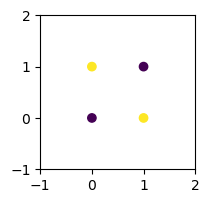

In [34]:
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.scatter('x1','x2',data=xor_df,c='tgt')
ax.set_xlim(-1,2)
ax.set_ylim(-1,2)

In [36]:
xor_df['new'] = (-1)**xor_df['x1'] * (-1)**xor_df['x2']
xor_df

,x1,x2,tgt,new
0,0,0,0,1
1,0,1,1,-1
2,1,0,1,-1
3,1,1,0,1


In [41]:
model = linear_model.LogisticRegression().fit(xor_df[['new']],xor_df['tgt'])
model.predict(xor_df[['new']])

array([0, 1, 1, 0], dtype=int64)